66
normalised
The graph is composed of 1 connected component(s).


Starting computation for t=1.0 and k=15 and knn=3
Starting computation for t=1.0 and k=15
Chebyshev coefficients:
[ 1.06675496e+00 -3.84066806e-01  7.23938313e-02 -9.20696169e-03
  8.82485030e-04 -6.78349084e-05  4.35139806e-06 -2.39464071e-07
  1.15376022e-08 -4.94330453e-10  1.90674257e-11 -6.68762518e-13
  2.15049546e-14 -6.38413736e-16  1.76006457e-17 -4.52929126e-19]
m_0 (balanced)
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0. 

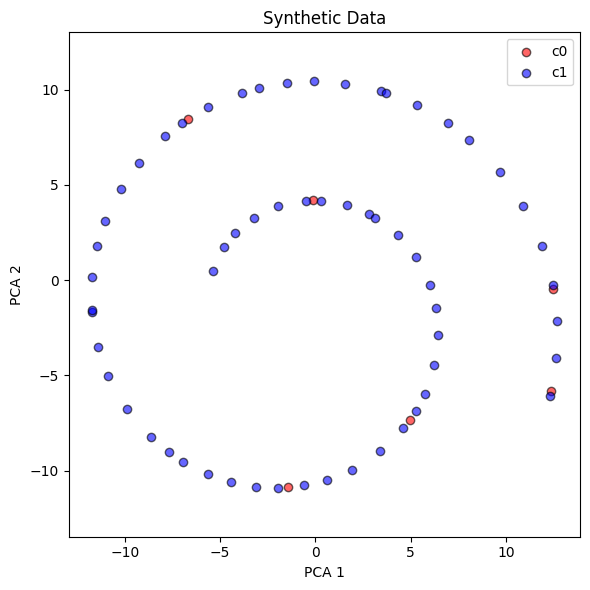

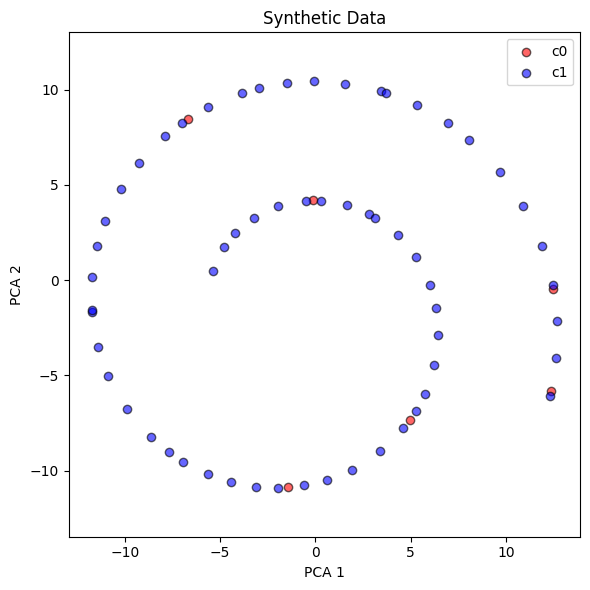

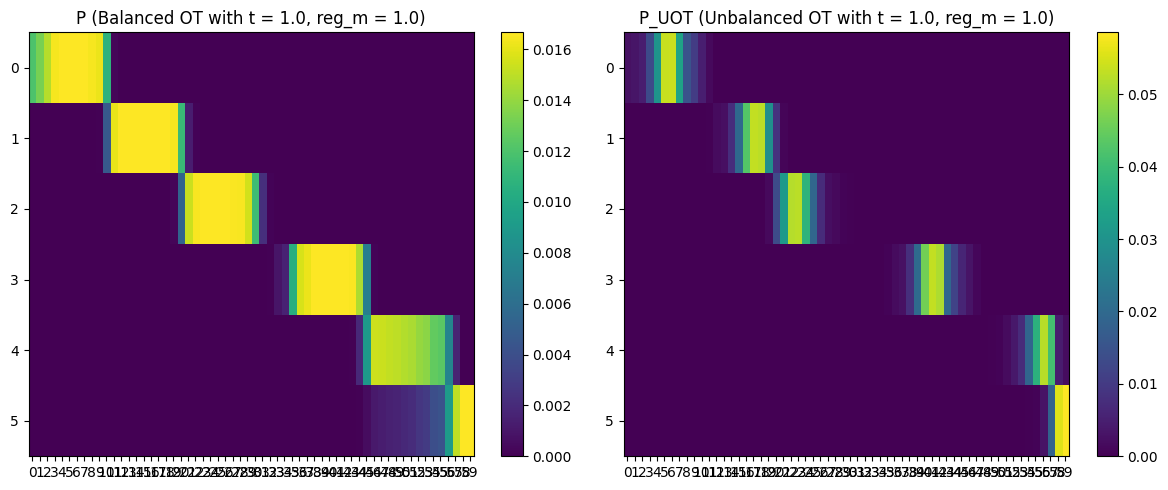

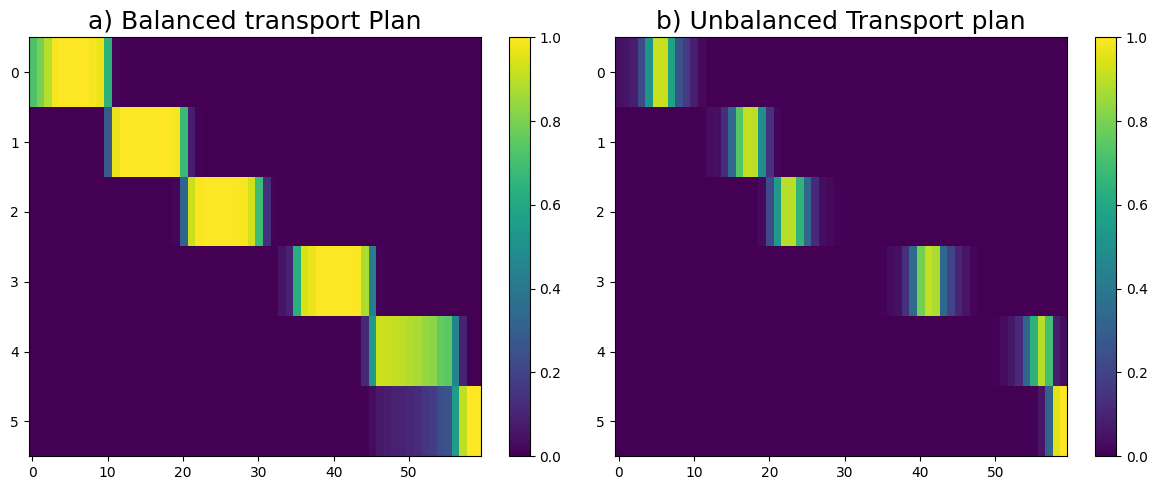

Mean P
Mean P_UOT
0.15191780056387938
0.05690515327129708
0.0
1.0
0.0
1.0
Mean P
Mean P_UOT
0.15191780056387938
0.05690515327129708


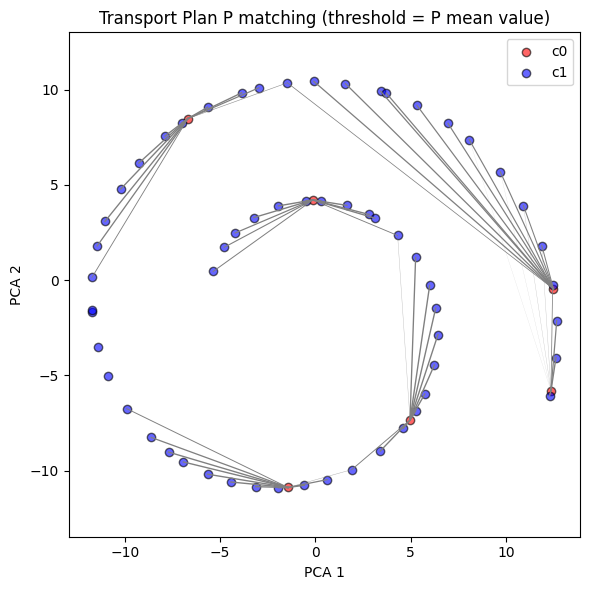

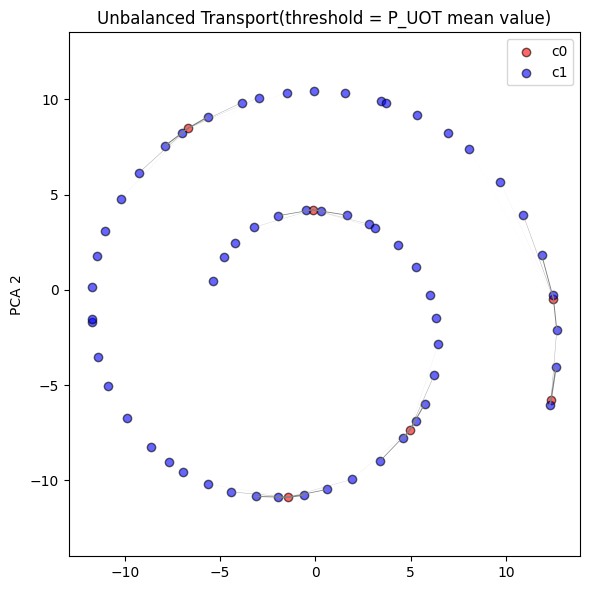

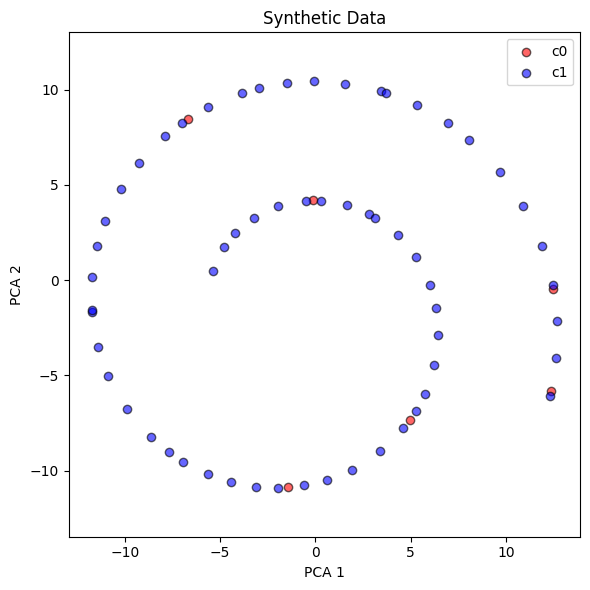

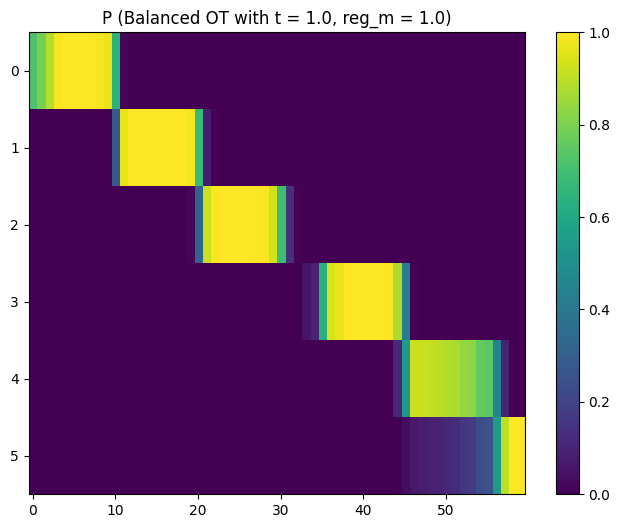

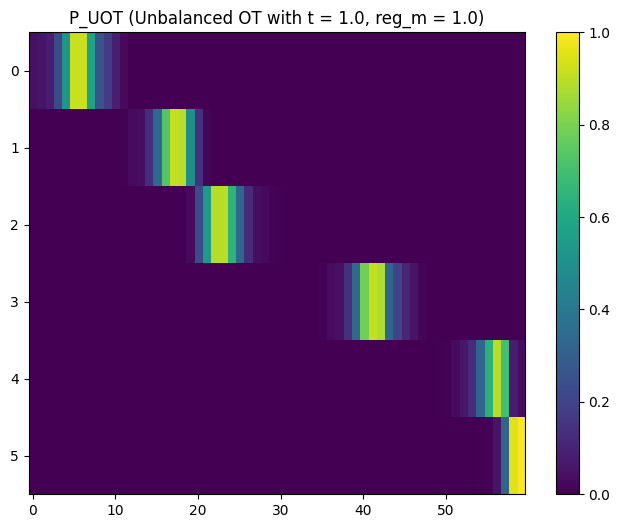

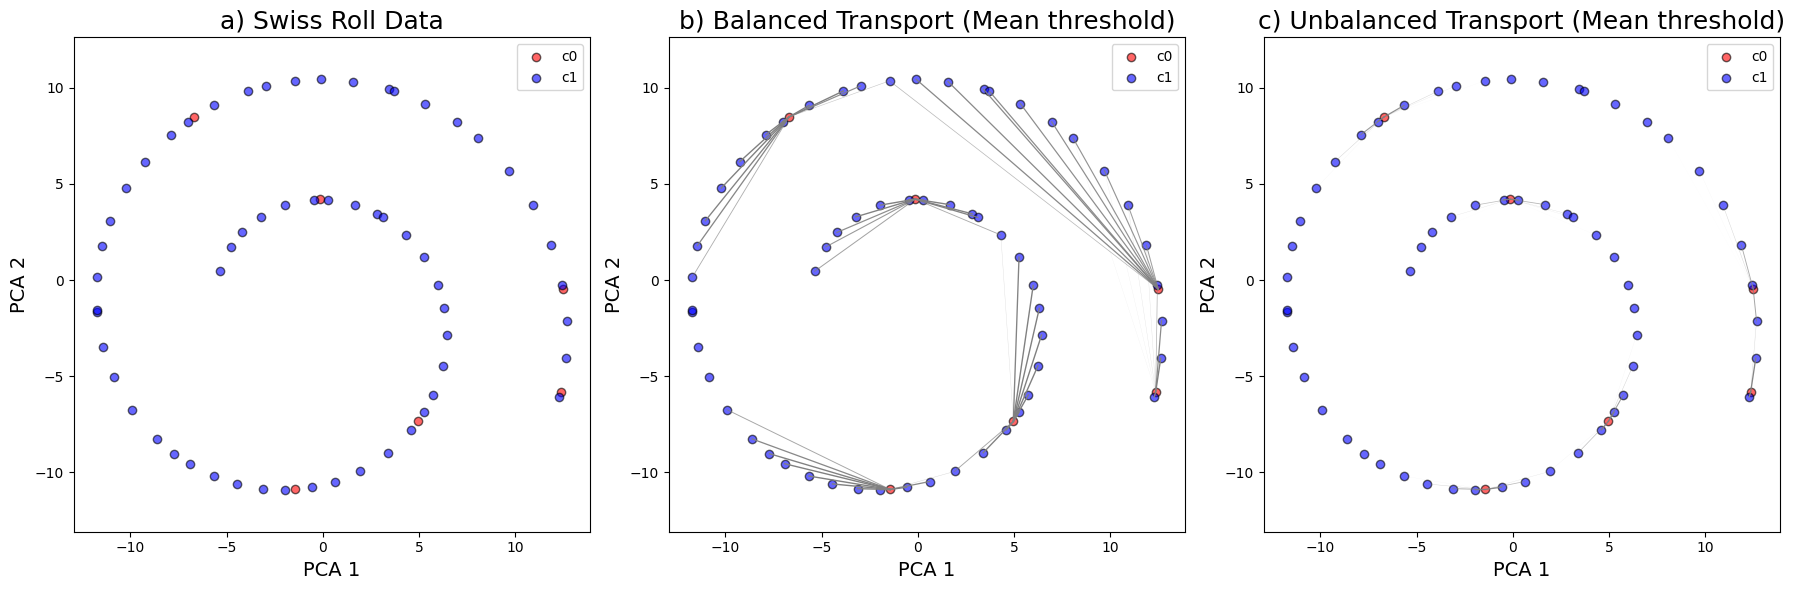

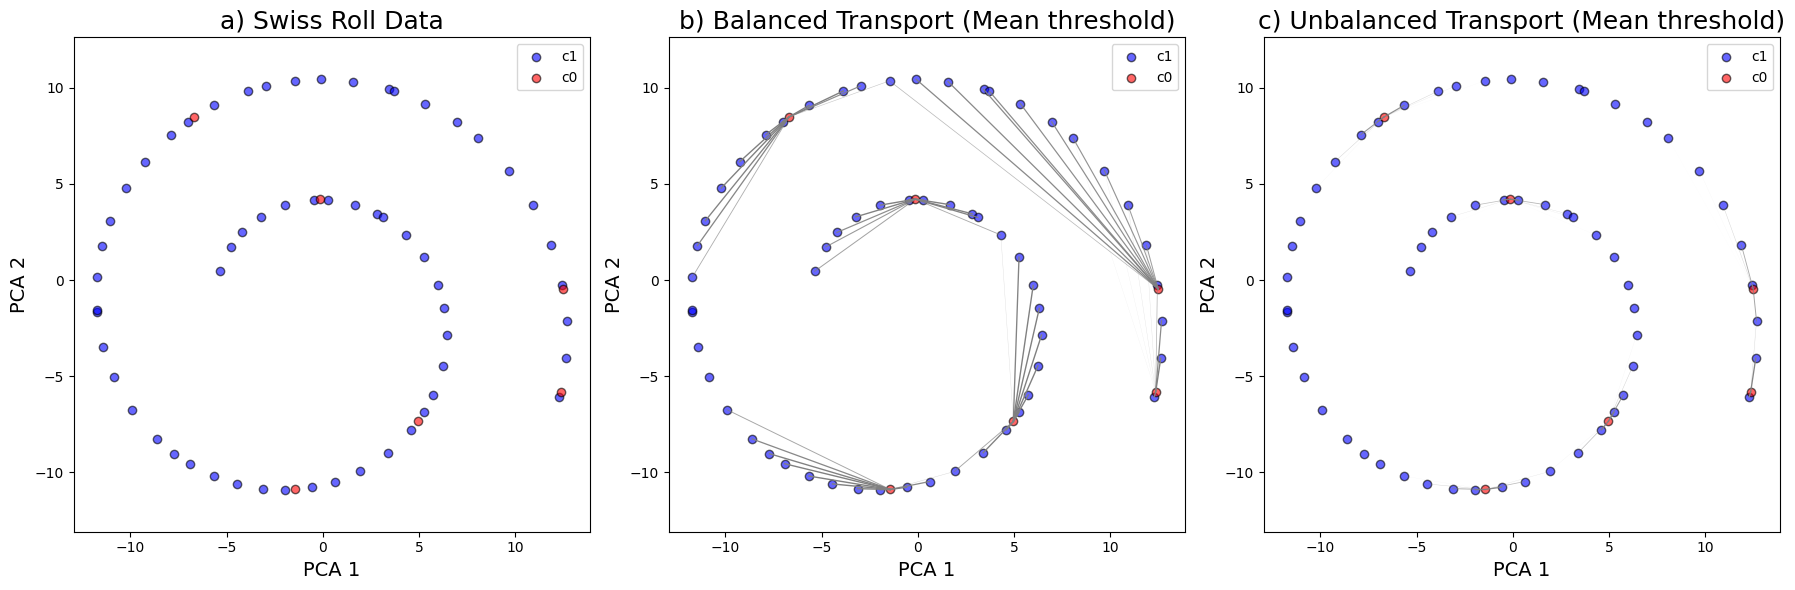

In [ ]:
import time
import signal
import sys
import convolutional_sinkhorn
import UOT_convolutional_sinkhorn
import matplotlib.pyplot as plt 
import numpy as np
import time
from scipy.sparse.linalg import eigsh 
from scipy.special import ive 
import graphtools
from scipy.sparse.linalg import eigsh 
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

start_time = time.time()
RESULT_FILE = '/Users/x/Documents/AD015/condition_matrix_1st_rep.csv'



def plot_pca(*c_arrays):

    all_data = np.vstack(c_arrays)
    
    
    labels = []
    for i, arr in enumerate(c_arrays):
        labels.extend([i] * len(arr))
    

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(all_data)

    plt.figure(figsize=(6, 6))
    colors = ['red', 'blue']
    
    for i, color in enumerate(colors):
        idx = np.array(labels) == i
        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                   label=f'c{i}', alpha=0.6, color=color, edgecolor='k')
    
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(f'Synthetic Data')
    plt.legend()
    plt.tight_layout()
    plt.axis('equal')
    plt.savefig('/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/pca_plot.png', dpi=500)
    



def reference_selection(data, n_clusters, random_state):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    kmeans.fit(data)
    return kmeans.cluster_centers_

# Function to save results and exit on SIGTERM
def save_results_and_exit(signum, frame):
    print(f"\nReceived termination signal {signum}. Saving results and exiting...")
    np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', header='m_0', comments='')
    sys.exit(0)  # Ensure graceful exit


signal.signal(signal.SIGTERM, save_results_and_exit)  # Catches SGE job termination
signal.signal(signal.SIGUSR1, save_results_and_exit)  # Optional custom signal


def compute_chebychev_coeff_all(phi, tau, K):
    return 2 * ive(np.arange(0, K + 1), -tau * phi)


def generate_gaussian_points(data, n_points, mean=0, std=0.5):
    gaussian_points = []
    for point in data:
        gaussian_points.append(np.random.normal(loc=point, scale=std, size=(n_points, len(point))))
    return np.array(gaussian_points)


def synthetic_data_generation(points,features,x0,xn, d0, dn, random_state=42):
    rng = np.random.default_rng(random_state)
    n = np.random.uniform(x0, xn)
    m = np.random.uniform(d0,dn)
    generated_data = np.random.normal(n,m,(points,features))
    return generated_data


def swirl(n, start, end, size, y_scale):
    u1 = np.random.uniform(start * np.pi, end* np.pi, n)
    v1 = np.random.uniform(0, size, n)
    x1 = u1 * np.cos(u1)
    y1 = v1
    z1 = u1 * np.sin(u1)
    c = np.vstack((x1, y1*y_scale, z1)).T
    return c
    


# Main function with try/except
def main():
    global condition_matrix  # Ensure access to the global variable

    try: 
        random_state = 42
        
        c0_1 = swirl(1,1.5, 2.1,20, 0.1)
        c0_2 = swirl(1,2.1, 2.7,20, 0.1)
        c0_3 = swirl(1,2.7, 3.3,20, 0.1)
        c0_4 = swirl(1,3.3, 3.9,20, 0.1)
        c0_5 = swirl(2,3.9, 4.5,20, 0.1)
        
        c0 = np.vstack((c0_1,c0_2,c0_3,c0_4,c0_5))
        c1 = swirl(2000, 1.5, 4.5, 20, 0.1)
        c1 = reference_selection(c1, 60, random_state)

        
        extra_col = np.zeros((c0.shape[0], 1))
        c0 = np.hstack((c0, extra_col))
        c0[:, 3] = c0[:, 0]**2 + c0[:, 2]**2
        sorted_indices = np.argsort(c0[:, 3])
        c0 = c0[sorted_indices]
        c0 = c0[:, :-1]

        
        extra_col = np.zeros((c1.shape[0], 1))
        c1 = np.hstack((c1, extra_col))
        c1[:, 3] = c1[:, 0]**2 + c1[:, 2]**2
        sorted_indices = np.argsort(c1[:, 3])
        c1 = c1[sorted_indices]
        c1 = c1[:, :-1]


        
        n_inner = c0.shape[0]
        n_outer = c1.shape[0]

        
        condition_sizes = [n_inner,n_outer]
        total_num_cells = sum(condition_sizes)
        print(total_num_cells)
        N = 2
        conditions =[]
        
        conditions.append(c0)
        conditions.append(c1)            
        plot_pca(c0, c1)
        cs = np.vstack(conditions)
        
        
        K = 0
        t_list = [1.0]
        k_list = [15]
        knn_list = [3]
        reg_m_list = [1.0]
    
          
        for knn in knn_list:

            graph = graphtools.Graph(cs , use_pygsp=True, knn=knn)
            graph.compute_laplacian("normalized")  # Compute normalized Laplacian
            print('normalised')
            L = graph.L


            n_components, labels = connected_components(csgraph=L, directed=False, connection='weak')
            print(f"The graph is composed of {n_components} connected component(s).")

            for k in k_list:
                for t in t_list:
                    for reg_m in reg_m_list:

                  
                        print(f"\n\nStarting computation for t={t} and k={k} and knn={knn}")
                        condition_matrix_balanced = np.zeros((N,N))
                        condition_matrix_unbalanced = np.zeros((N,N))
                        
                        print(f"Starting computation for t={t} and k={k}")

                        phi = eigsh(L, k=k, return_eigenvectors=False)[0] / 2  # Compute the largest eigenvalue divided by 2
                        coeff = compute_chebychev_coeff_all(phi, t, k)  # Compute Chebyshev coefficients
                        print("Chebyshev coefficients:")
                        print(coeff)

                        for A, _ in enumerate(conditions):
                            for B, _ in enumerate(conditions): 
                                if B > A:
                                    start_A = sum(condition_sizes[:A])
                                    end_A = start_A + condition_sizes[A] - 1
                                    start_B = sum(condition_sizes[:B])
                                    end_B = start_B + condition_sizes[B] - 1

                                    m_0 = np.zeros(total_num_cells,)
                                    m_0[start_A:end_A+1] = 1
                                    m_0 = m_0 / np.sum(m_0) 
                                    print('m_0 (balanced)')
                                    print(m_0)
                                    m_1 = np.zeros(total_num_cells,)
                                    m_1[start_B:end_B+1] = 1
                                    m_1 = m_1 / np.sum(m_1)
                                    print('m_1 (balanced)')
                                    print(m_1)
                                    
                                    N = len(m_0)
                                    a = np.ones(N) / N
                                    
                                    dist_w, P = convolutional_sinkhorn.fastcheb_conv_sinkhorn(L, m_0, m_1, phi, coeff, t=t, k=k, verbose = True,  P=K)
                                    print ('Balanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
    
                                    P_cropped = P[:condition_sizes[0],condition_sizes[0]:]
                                    
                                    condition_matrix_balanced[A, B] = dist_w
                                    condition_matrix_balanced[B, A] = dist_w
                                    
                                    start_A_UOT = sum(condition_sizes[:A])
                                    end_A_UOT = start_A_UOT + condition_sizes[A] - 1
                                    start_B_UOT = sum(condition_sizes[:B])
                                    end_B_UOT = start_B_UOT + condition_sizes[B] - 1

                                    m_0_UOT = np.zeros(total_num_cells,)
                                    m_0_UOT[start_A_UOT:end_A_UOT+1] = 1
                            
                                    print('m_0_UOT (unbalanced)')
                                    print(m_0_UOT)
                                    
                                    m_1_UOT = np.zeros(total_num_cells,)
                                    m_1_UOT[start_B_UOT:end_B_UOT+1] = 1
                                    print('m_1 (unbalanced)')
                                    print(m_1_UOT)

                                    dist_w_UOT, P_UOT = UOT_convolutional_sinkhorn.fastcheb_conv_sinkhorn(L, m_0_UOT, m_1_UOT, phi, coeff,reg_m, t=t, k=k, verbose = True, P=K)
                                    print ('Unbalanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
                        
                    
                                    P_UOT_cropped = P_UOT[:condition_sizes[0],condition_sizes[0]:]
                                
                                    condition_matrix_unbalanced[A, B] = dist_w_UOT
                                    condition_matrix_unbalanced[B, A] = dist_w_UOT
                        
                                
                                    P_norm = P * a
                                    P_UOT_norm = P_UOT * a
                                    
                                    P_norm_cropped = P_norm[:condition_sizes[0],condition_sizes[0]:]
                                    P_UOT_norm_cropped = P_UOT_norm[:condition_sizes[0],condition_sizes[0]:]
                                    
                                    all_data = np.vstack([c0,c1])
    
                                    
                                    labels = []
                                    for i, arr in enumerate([c0,c1]):
                                        labels.extend([i] * len(arr))
                                    

                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)

                                    plt.figure(figsize=(6, 6))
                                    colors = ['red', 'blue']
                                    
                                    for i, color in enumerate(colors):
                                        idx = np.array(labels) == i
                                        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                                                label=f'c{i}', alpha=0.6, color=color, edgecolor='k')
                                    
                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title(f'Synthetic Data')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                    plt.savefig('/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/pca_plot.png', dpi=500)
                                    
                                    
                                    
                        
                                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                                    im_p = axes[0].imshow(P_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[0].set_title(f'P (Balanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar(im_p, ax=axes[0])

                                    im_pu = axes[1].imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[1].set_title(f'P_UOT (Unbalanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar(im_pu, ax=axes[1])
                                    

                                    # Set ticks for both subplots
                                    for ax in axes:
                                        ax.set_xticks(np.arange(0, P_cropped.shape[1], 1))
                                        ax.set_yticks(np.arange(0, P_cropped.shape[0], 1))

                                    plt.tight_layout()
                           
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/P_and_PUOT_heatmap.png', dpi=500)
                                    
                                    
                                    
                                    
                                    
                            
                                    P_norm_cropped =  P_norm_cropped/np.max(P_norm_cropped)
                                    P_UOT_norm_cropped =  P_UOT_norm_cropped/np.max(P_UOT_norm_cropped)
                                    P_mean = np.mean(P_norm_cropped)
                                    P_UOT_mean = np.mean(P_UOT_norm_cropped)
                                    
                                    
                                    
                                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                                    im_p = axes[0].imshow(P_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[0].set_title(f'a) Balanced transport Plan', fontsize = 18)
                                    plt.colorbar(im_p, ax=axes[0])

                                    im_pu = axes[1].imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[1].set_title(f'b) Unbalanced Transport plan',fontsize = 18)
                                    plt.colorbar(im_pu, ax=axes[1])
                                    

                                    # Set ticks for both subplots
                                    '''
                                    for ax in axes:
                                        ax.set_xticks(np.arange(0, P_cropped.shape[1], 1))
                                        ax.set_yticks(np.arange(0, P_cropped.shape[0], 1))
                                    '''

                                    plt.tight_layout()
                              
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/Normalised_P_and_PUOT_heatmap.png', dpi=500)
                                    plt.show()
                                    
                                    print('Mean P')
                                    print('Mean P_UOT')
                                    print(P_mean)
                                    print(P_UOT_mean)
                                    
                                    all_data = np.vstack([c0, c1])
                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)
                                    c0_pca = pca_result[:len(c0)]
                                    c1_pca = pca_result[len(c0):]
                                    colors = ['red', 'blue']

                                    plt.figure(figsize=(6, 6))
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_norm_cropped.shape[1]):
                                            strength = P_norm_cropped[i, j]
                                            if strength > P_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                plt.plot([x0, x1], [y0, y1], color='gray', alpha= min(strength*2, 1), linewidth=strength)
                                    for i, arr in enumerate([c0_pca, c1_pca]):
                                        plt.scatter(arr[:, 0], arr[:, 1], label=f'c{i}', color= colors[i], alpha=0.6, edgecolor='k')
                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title('Transport Plan P matching (threshold = P mean value)')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/P_transport_matching.png', dpi=500)

                                    plt.figure(figsize=(6, 6))
                                    for i, arr in enumerate([c0_pca, c1_pca]):
                                        plt.scatter(arr[:, 0], arr[:, 1], label=f'c{i}', color=colors[i], alpha=0.6, edgecolor='k')
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_UOT_norm_cropped.shape[1]):
                                            strength = P_UOT_norm_cropped[i, j]
                                            if strength > P_UOT_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                plt.plot([x0, x1], [y0, y1], color='gray', alpha=min(strength*2, 1) , linewidth= strength)
                                    plt.ylabel('PCA 2')
                                    plt.title('Unbalanced Transport(threshold = P_UOT mean value)')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                  
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/PUOT_transport_matching.png', dpi=500)
                                    
                                    labels = []
                                    for i, arr in enumerate([c0,c1]):
                                        labels.extend([i] * len(arr))
                                    

                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)

                                    plt.figure(figsize=(6, 6))
                                    colors = ['red', 'blue']
                                    
                                    for i, color in enumerate(colors):
                                        idx = np.array(labels) == i
                                        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                                                label=f'c{i}', alpha=0.6, color=color, edgecolor='k')
                                    
                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title(f'Synthetic Data')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                    plt.savefig('/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/pca_plot.png', dpi=500)

                                    P_min = np.min(P_norm_cropped)
                                    print(P_min)
                                    P_max = np.max(P_norm_cropped)
                                    print(P_max)
                                    P_norm_cropped = (P_norm_cropped - P_min) / (P_max - P_min)
                                    
                                    P_min = np.min(P_UOT_norm_cropped)
                                    print(P_min)
                                    P_max = np.max(P_UOT_norm_cropped)
                                    print(P_max)
                                    P_UOT_norm_cropped = (P_UOT_norm_cropped - P_min) / (P_max - P_min)
                                    
                                    plt.figure(figsize=(8, 6))
                                    plt.imshow(P_norm_cropped, cmap='viridis', aspect='auto')
                                    plt.title(f'P (Balanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar()
                                
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/Normalised_P_heatmap.png', dpi=500)

                                    plt.figure(figsize=(8, 6))
                                    plt.imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto')
                                    plt.title(f'P_UOT (Unbalanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar()
                               
                     
                         
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/Normalised_PUOT_heatmap.png', dpi=500)
                                
    
                                    print('Mean P')
                                    print('Mean P_UOT')
                                    print(P_mean)
                                    print(P_UOT_mean)

                                    all_data = np.vstack([c0, c1])
                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)
                                    c0_pca = pca_result[:len(c0)]
                                    c1_pca = pca_result[len(c0):]
                                    colors = ['red', 'blue']
                                    labels = []
                                    for i, arr in enumerate([c0, c1]):
                                        labels.extend([i] * len(arr))
                                    labels = np.array(labels)

                                    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                                    ax = axes[0]
                                    for i, color in enumerate(colors):
                                        idx = labels == i
                                        ax.scatter(pca_result[idx, 0], pca_result[idx, 1], label=f'c{i}', alpha=0.6, color=color, edgecolor='k')
                                    ax.set_xlabel('PCA 1', fontsize = 14)
                                    ax.set_ylabel('PCA 2', fontsize = 14)
                                    ax.set_title('a) Swiss Roll Data', fontsize = 18)
                                    ax.legend()
                                    ax.axis('equal')

                                    # Plot 1: Transport Plan P matching
                                    ax = axes[1]
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_norm_cropped.shape[1]):
                                            strength = P_norm_cropped[i, j]
                                            if strength > P_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                ax.plot([x0, x1], [y0, y1], color='gray', alpha=min(strength, 1), linewidth=strength)
                                    for i, arr in enumerate([c0_pca, c1_pca]):
                                        ax.scatter(arr[:, 0], arr[:, 1], label=f'c{i}', color=colors[i], alpha=0.6, edgecolor='k')
                                    ax.set_xlabel('PCA 1', fontsize = 14)
                                    ax.set_ylabel('PCA 2', fontsize = 14)
                                    ax.set_title('b) Balanced Transport (Mean threshold)', fontsize = 18)
                                    ax.legend()
                                    ax.axis('equal')

                                    # Plot 2: Transport Plan P_UOT matching
                                    ax = axes[2]
                                    for i, arr in enumerate([c0_pca, c1_pca]):
                                        ax.scatter(arr[:, 0], arr[:, 1], label=f'c{i}', color=colors[i], alpha=0.6, edgecolor='k')
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_UOT_norm_cropped.shape[1]):
                                            strength = P_UOT_norm_cropped[i, j]
                                            if strength > P_UOT_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                ax.plot([x0, x1], [y0, y1], color='gray', alpha=min(strength, 1), linewidth=strength)
                                    ax.set_xlabel('PCA 1', fontsize = 14)
                                    ax.set_ylabel('PCA 2', fontsize = 14)
                                    ax.set_title('c) Unbalanced Transport (Mean threshold)', fontsize = 18)
                                    ax.legend()
                                    ax.axis('equal')

                                    # Plot 3: PCA of synthetic data
                                

                                    plt.tight_layout()
                                    plt.savefig('/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/combined_transport_matching.png', dpi=500)

                                    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

                                    # Plot 0: Swiss Roll Data (PCA)
                                    ax = axes[0]
                                    # Plot c1 first, then c0
                                    ax.scatter(pca_result[labels == 1, 0], pca_result[labels == 1, 1], label='c1', alpha=0.6, color=colors[1], edgecolor='k')
                                    ax.scatter(pca_result[labels == 0, 0], pca_result[labels == 0, 1], label='c0', alpha=0.6, color=colors[0], edgecolor='k')
                                    ax.set_xlabel('PCA 1', fontsize=14)
                                    ax.set_ylabel('PCA 2', fontsize=14)
                                    ax.set_title('a) Swiss Roll Data', fontsize=18)
                                    ax.legend()
                                    ax.axis('equal')

                                    # Plot 1: Transport Plan P matching
                                    ax = axes[1]
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_norm_cropped.shape[1]):
                                            strength = P_norm_cropped[i, j]
                                            if strength > P_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                ax.plot([x0, x1], [y0, y1], color='gray', alpha=min(strength, 1), linewidth=strength)
                                    # Plot c1 first, then c0
                                    ax.scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', color=colors[1], alpha=0.6, edgecolor='k')
                                    ax.scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', color=colors[0], alpha=0.6, edgecolor='k')
                                    ax.set_xlabel('PCA 1', fontsize=14)
                                    ax.set_ylabel('PCA 2', fontsize=14)
                                    ax.set_title('b) Balanced Transport (Mean threshold)', fontsize=18)
                                    ax.legend()
                                    ax.axis('equal')

                                    # Plot 2: Transport Plan P_UOT matching
                                    ax = axes[2]
                                    # Plot c1 first, then c0
                                    ax.scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', color=colors[1], alpha=0.6, edgecolor='k')
                                    ax.scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', color=colors[0], alpha=0.6, edgecolor='k')
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_UOT_norm_cropped.shape[1]):
                                            strength = P_UOT_norm_cropped[i, j]
                                            if strength > P_UOT_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                ax.plot([x0, x1], [y0, y1], color='gray', alpha=min(strength, 1), linewidth=strength)
                                    ax.set_xlabel('PCA 1', fontsize=14)
                                    ax.set_ylabel('PCA 2', fontsize=14)
                                    ax.set_title('c) Unbalanced Transport (Mean threshold)', fontsize=18)
                                    ax.legend()
                                    ax.axis('equal')

                                    plt.tight_layout()
                                    plt.savefig('/Users/x/Documents/POT_unbalanced/mixed_swiss_roll_plots/combined_transport_matching.png', dpi=500)

                                                        

         
    except KeyboardInterrupt:
        print("\nJob interrupted manually (CTRL+C). Saving results...")
        np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', comments='')


if __name__ == '__main__':
    main()